In [2]:
import tensorflow as tf
print('GPU available:', tf.config.list_physical_devices('GPU'))


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:

!pip install -q fasttext-wheel


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 120.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.2/314.2 kB 32.6 MB/s eta 0:00:00


In [4]:
import os, re, string, warnings, random, pickle, gc

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')

# Reproducibility (seed = student ID)
STUDENT_ID  = 33649642
RANDOM_SEED = STUDENT_ID

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)


In [5]:
import tensorflow as tf
tf.random.set_seed(RANDOM_SEED)

from tensorflow.keras.preprocessing.text  import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models  import Sequential, Model
from tensorflow.keras.layers  import (
    Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D,
    Flatten, Dense, Dropout, Input, Concatenate,
    SpatialDropout1D, BatchNormalization, Activation
)
from tensorflow.keras.callbacks  import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, auc, accuracy_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")



TensorFlow : 2.20.0
NumPy      : 2.0.2
Pandas     : 2.2.2


In [6]:

!pip install -q gdown

import gdown
import pandas as pd
import time

# read google drive file for dataset link
file_id = "1ROoO-Dkm46zSFw1B5NzgH8Lz-1633WPj"

DATA_PATH = "/content/review_20252026_standard.csv"

url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(url, DATA_PATH, quiet=False)

# read CSV
start = time.time()

df = pd.read_csv(DATA_PATH)

print("Loaded in", round(time.time() - start, 2), "seconds")
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

df.head(3)


Downloading...
From (original): https://drive.google.com/uc?id=1ROoO-Dkm46zSFw1B5NzgH8Lz-1633WPj
From (redirected): https://drive.google.com/uc?id=1ROoO-Dkm46zSFw1B5NzgH8Lz-1633WPj&confirm=t&uuid=32d724ec-dd1a-4e0a-bf75-50f53bf112dd
To: /content/review_20252026_standard.csv
100%|██████████| 288M/288M [00:06<00:00, 41.9MB/s]


Loaded in 2.96 seconds
Dataset shape: (20983, 3)
Columns: ['id', 'sentiment', 'review']

Missing values:
 id           0
sentiment    0
review       0
dtype: int64

Data types:
 id           object
sentiment     int64
review       object
dtype: object


,id,sentiment,review
0,"""5814_8""",1,"""With all this stuff going down at the moment ..."
1,"""7759_3""",0,"""The film starts with a manager (Nicholas Bell..."
2,"""3630_4""",0,"""It must be assumed that those who praised thi..."


Sentiment distribution:
  Negative (0): 10,491  (50.0%)
  Positive (1): 10,492  (50.0%)


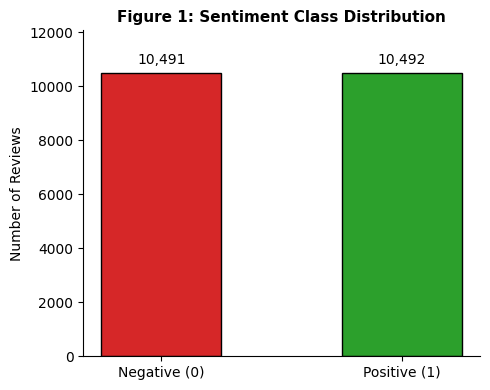

In [7]:
# Class distribution
import matplotlib.pyplot as plt
import seaborn as sns
class_counts = df['sentiment'].value_counts().sort_index()
print("Sentiment distribution:")
print(f"  Negative (0): {class_counts[0]:,}  ({class_counts[0]/len(df)*100:.1f}%)")
print(f"  Positive (1): {class_counts[1]:,}  ({class_counts[1]/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Negative (0)', 'Positive (1)'],
              class_counts.values,
              color=['#d62728', '#2ca02c'], edgecolor='black', width=0.5)
ax.bar_label(bars, fmt='{:,.0f}', padding=4)
ax.set_title('Figure 1: Sentiment Class Distribution', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Reviews')
ax.set_ylim(0, max(class_counts.values) * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig('fig1_sentiment_distribution.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [8]:
import re
def clean_text(text: str) -> str:
    """
    Pipeline:
      1. Strip HTML tags (e.g. <br />)
      2. Remove URLs
      3. Remove non-alphabetic characters
      4. Lowercase and normalise whitespace
    """
    text = re.sub(r'<[^>]+>', ' ', str(text))          # HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' ', text)      # URLs
    text = re.sub(r'[^a-zA-Z\s]',      ' ', text)      # non-alpha
    return ' '.join(text.lower().split())               # lowercase + spaces

df['clean_review'] = df['review'].apply(clean_text)

# Sanity check
print("── Original (first 250 chars) ──────────────────────────")
print(df['review'].iloc[0][:250])
print("\n── Cleaned  (first 250 chars) ──────────────────────────")
print(df['clean_review'].iloc[0][:250])

── Original (first 250 chars) ──────────────────────────
"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thoug

── Cleaned  (first 250 chars) ──────────────────────────
with all this stuff going down at the moment with mj i ve started listening to his music watching the odd documentary here and there watched the wiz and watched moonwalker again maybe i just want to get a certain insight into this guy who i thought w


In [9]:
import numpy as np

# Word-count/review
df['word_count'] = df['clean_review'].apply(lambda x: len(x.split()))

print("\nReview length statistics (words after cleaning):")
print(df['word_count'].describe().round(2))

print("\nPercentiles:")
for pct in [75, 85, 90, 95, 99]:
    val = int(np.percentile(df['word_count'], pct))
    print(f"{pct}th percentile: {val} words")
# Word-count/review
df['word_count'] = df['clean_review'].apply(lambda x: len(x.split()))

print("\nReview length statistics (words after cleaning):")
print(df['word_count'].describe().round(2))
print()
for pct in [75, 85, 90, 95, 99]:
    val = int(np.percentile(df['word_count'], pct))
    print(f"  {pct}th percentile : {val} words")



Review length statistics (words after cleaning):
count    20983.00
mean       237.11
std        177.02
min         10.00
25%        129.00
50%        177.00
75%        287.00
max       2494.00
Name: word_count, dtype: float64

Percentiles:
75th percentile: 287 words
85th percentile: 382 words
90th percentile: 464 words
95th percentile: 609 words
99th percentile: 929 words

Review length statistics (words after cleaning):
count    20983.00
mean       237.11
std        177.02
min         10.00
25%        129.00
50%        177.00
75%        287.00
max       2494.00
Name: word_count, dtype: float64

  75th percentile : 287 words
  85th percentile : 382 words
  90th percentile : 464 words
  95th percentile : 609 words
  99th percentile : 929 words


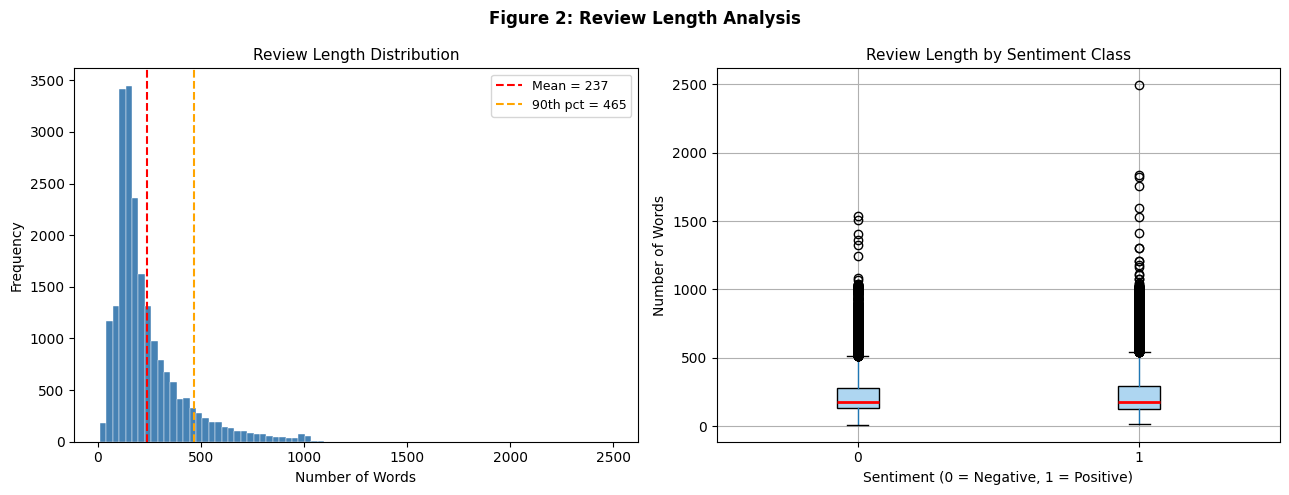

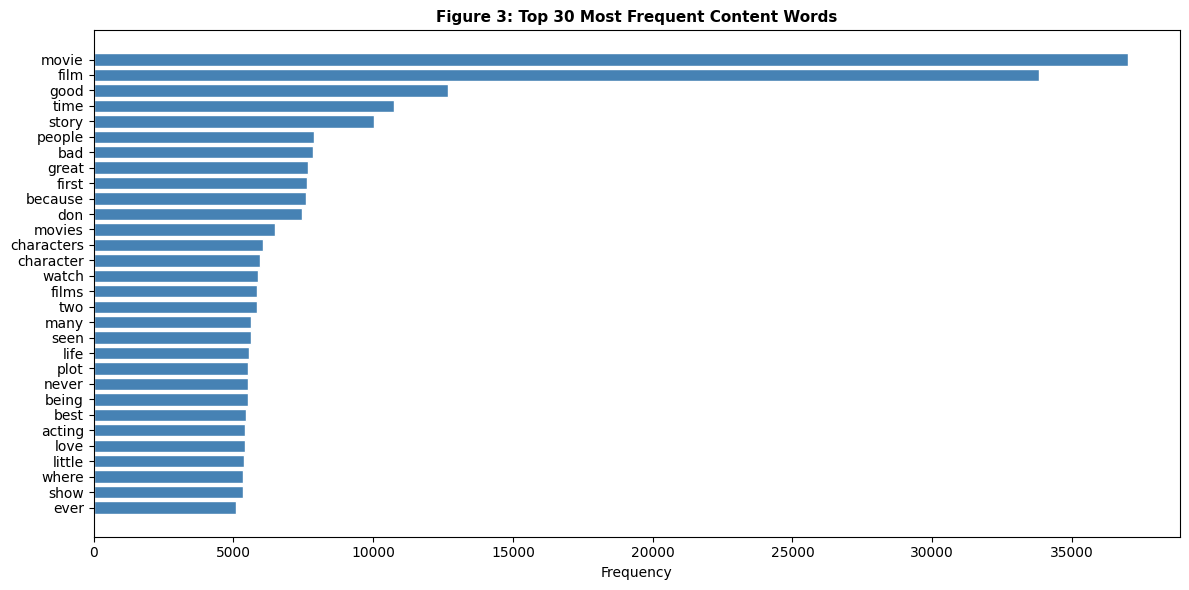

Top 10 content words:
  'movie': 37,014
  'film': 33,805
  'good': 12,691
  'time': 10,742
  'story': 10,034
  'people': 7,870
  'bad': 7,834
  'great': 7,656
  'first': 7,634
  'because': 7,589


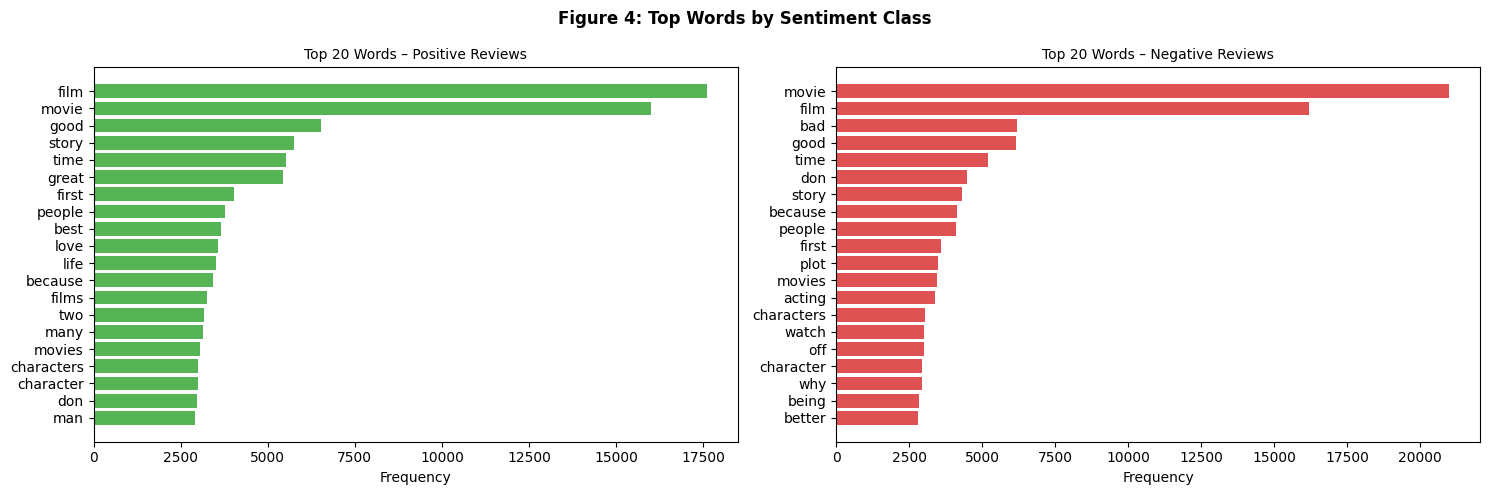

In [10]:
from collections import Counter

# Figure 2 – Review length distribution + box plot by class
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(df['word_count'], bins=80,
             color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(df['word_count'].mean(),
                color='red', linestyle='--',
                label=f"Mean = {df['word_count'].mean():.0f}")
axes[0].axvline(np.percentile(df['word_count'], 90),
                color='orange', linestyle='--',
                label=f"90th pct = {np.percentile(df['word_count'], 90):.0f}")
axes[0].set_title('Review Length Distribution', fontsize=11)
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

# Box plot by sentiment
df.boxplot(column='word_count', by='sentiment', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='#AED6F1'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Review Length by Sentiment Class', fontsize=11)
axes[1].set_xlabel('Sentiment (0 = Negative, 1 = Positive)')
axes[1].set_ylabel('Number of Words')
plt.suptitle('Figure 2: Review Length Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_review_length.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Top 30 words
STOP_WORDS = {
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'it','is','was','be','as','by','that','this','i','he','she','they','we',
    'you','from','are','were','been','have','has','had','do','did','not','no',
    'so','if','all','its','his','her','their','my','me','him','us','about',
    'into','than','then','there','what','which','who','when','how','just','up',
    'out','also','can','get','one','more','very','some','would','will','could',
    'should','even','much','like','after','before','through','over','same',
    'too','see','way','make','made','well','back','come','came','most','each',
    'now','know','think','really','only','any','other','these','those','them'
}

all_words    = ' '.join(df['clean_review']).split()
word_freq    = Counter(w for w in all_words
                       if w not in STOP_WORDS and len(w) > 2)
top30        = word_freq.most_common(30)
top30_df     = pd.DataFrame(top30, columns=['word', 'count'])

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top30_df['word'][::-1], top30_df['count'][::-1],
        color='steelblue', edgecolor='white')
ax.set_title('Figure 3: Top 30 Most Frequent Content Words', fontsize=11, fontweight='bold')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('fig3_top_words.pdf', format='pdf', bbox_inches='tight')
plt.show()

print("Top 10 content words:")
for w, c in top30[:10]:
    print(f"  '{w}': {c:,}")


pos_freq = Counter(
    w for rev in df[df['sentiment']==1]['clean_review']
    for w in rev.split() if w not in STOP_WORDS and len(w) > 2
)
neg_freq = Counter(
    w for rev in df[df['sentiment']==0]['clean_review']
    for w in rev.split() if w not in STOP_WORDS and len(w) > 2
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, freq, title, color in zip(
        axes,
        [pos_freq, neg_freq],
        ['Top 20 Words – Positive Reviews',
         'Top 20 Words – Negative Reviews'],
        ['#2ca02c', '#d62728']):
    top20  = freq.most_common(20)
    wds, cts = zip(*top20)
    ax.barh(list(wds)[::-1], list(cts)[::-1], color=color, alpha=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Frequency')

plt.suptitle('Figure 4: Top Words by Sentiment Class', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_words_by_sentiment.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [11]:
from tensorflow.keras.preprocessing.text  import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Hyperparameters
MAX_WORDS = 20_000   # vocabulary cap
MAX_LEN   = 400      # sequence length (covers ~85th-90th percentile)
EMBED_DIM = 300      # embedding dimension


tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_review'])

word_index = tokenizer.word_index
vocab_size = min(len(word_index) + 1, MAX_WORDS + 1)

print(f"Unique tokens in corpus : {len(word_index):,}")
print(f"Effective vocabulary    : {vocab_size:,}")

sequences = tokenizer.texts_to_sequences(df['clean_review'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df['sentiment'].values

print(f"Input tensor  X : {X.shape}")
print(f"Label vector  y : {y.shape}")

Unique tokens in corpus : 68,384
Effective vocabulary    : 20,001
Input tensor  X : (20983, 400)
Label vector  y : (20983,)


In [15]:
from sklearn.model_selection import train_test_split

STUDENT_ID  = 33649642
RANDOM_SEED = STUDENT_ID

# Train (70%) / Validation (10%) / Test (20%)
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.125,
    random_state=RANDOM_SEED, stratify=y_tv
)
print(f"Train      : {X_train.shape[0]:,}")
print(f"Validation : {X_val.shape[0]:,}")
print(f"Test       : {X_test.shape[0]:,}")

import pickle
with open('tokenizer_33649642.pkl', 'wb') as fh:
    pickle.dump(tokenizer, fh)
print("Tokeniser saved.")

# using the 300-dimension variant.

!wget -q http://nlp.stanford.edu/data/glove.6B.zip && unzip -q glove.6B.zip
print('GloVe downloaded.')

Train      : 14,687
Validation : 2,099
Test       : 4,197
Tokeniser saved.
GloVe downloaded.


In [16]:
GLOVE_PATH = 'glove.6B.300d.txt'

def build_glove_matrix(glove_path: str, word_index: dict,
                       embed_dim: int, max_words: int) -> np.ndarray:
    """Load GloVe vectors and build a weight matrix aligned to our vocabulary."""
    vsz = min(len(word_index) + 1, max_words + 1)
    mat = np.zeros((vsz, embed_dim), dtype='float32')
    found = 0
    with open(glove_path, 'r', encoding='utf-8') as fh:
        for line in fh:
            parts = line.split()
            word  = parts[0]
            if word in word_index and word_index[word] < max_words:
                mat[word_index[word]] = np.array(parts[1:], dtype='float32')
                found += 1
    print(f"GloVe  : {found:,} / {vsz:,} tokens mapped  "
          f"({found/vsz*100:.1f}% coverage)")
    return mat

glove_matrix = build_glove_matrix(GLOVE_PATH, word_index, EMBED_DIM, MAX_WORDS)
print(f"GloVe matrix shape : {glove_matrix.shape}")


!wget -q https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.bin.gz
!gunzip cc.en.300.bin.gz
print('fastText model ready.')


GloVe  : 19,844 / 20,001 tokens mapped  (99.2% coverage)
GloVe matrix shape : (20001, 300)
fastText model ready.


In [17]:
import gc

!pip install fasttext-wheel
import fasttext
FT_MODEL_PATH = 'cc.en.300.bin'
ft = fasttext.load_model(FT_MODEL_PATH)
print(f"fastText model loaded  (dim={ft.get_dimension()})")

def build_fasttext_matrix(ft_model, word_index: dict,
                           embed_dim: int, max_words: int) -> np.ndarray:
    """Build embedding matrix using fastText (OOV words get subword vectors)."""
    vsz = min(len(word_index) + 1, max_words + 1)
    mat = np.zeros((vsz, embed_dim), dtype='float32')
    found = 0
    for word, idx in word_index.items():
        if idx < max_words:
            vec = ft_model.get_word_vector(word)
            if np.any(vec):
                mat[idx] = vec
                found += 1
    print(f"fastText: {found:,} / {vsz:,} tokens mapped  "
          f"({found/vsz*100:.1f}% coverage)")
    return mat

fasttext_matrix = build_fasttext_matrix(ft, word_index, EMBED_DIM, MAX_WORDS)
print(f"fastText matrix shape : {fasttext_matrix.shape}")

del ft
gc.collect()



fastText model loaded  (dim=300)
fastText: 19,999 / 20,001 tokens mapped  (100.0% coverage)
fastText matrix shape : (20001, 300)


0

In [18]:
import tensorflow as tf
def build_sequential_cnn(embedding_matrix: np.ndarray,
                          max_len: int,
                          embed_dim: int,
                          trainable: bool = False) -> tf.keras.Model:
    """
    Sequential ConvNet.

    Embedding → SpatialDropout(0.2) → Conv1D(128,5) → Conv1D(64,3) →
    MaxPool(3) → Conv1D(64,3) → MaxPool(3) → Flatten →
    Dense(128,relu) → Dropout(0.5) → Dense(64,relu) → Dropout(0.3) →
    Dense(1,sigmoid)
    """
    vsz = embedding_matrix.shape[0]

    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(vsz, embed_dim,
                  weights=[embedding_matrix],
                  input_length=max_len,
                  trainable=trainable,
                  name='embedding'),
        tf.keras.layers.SpatialDropout1D(0.2,   name='spatial_dropout'),
        tf.keras.layers.Conv1D(128, 5, activation='relu', padding='same', name='conv1'),
        tf.keras.layers.Conv1D(64,  3, activation='relu', padding='same', name='conv2'),
        tf.keras.layers.MaxPooling1D(3,         name='maxpool1'),
        tf.keras.layers.Conv1D(64,  3, activation='relu', padding='same', name='conv3'),
        tf.keras.layers.MaxPooling1D(3,         name='maxpool2'),
        tf.keras.layers.Flatten(                name='flatten'),
        tf.keras.layers.Dense(128, activation='relu',    name='dense1'),
        tf.keras.layers.Dropout(0.5,            name='dropout1'),
        tf.keras.layers.Dense(64,  activation='relu',    name='dense2'),
        tf.keras.layers.Dropout(0.3,            name='dropout2'),
        tf.keras.layers.Dense(1,   activation='sigmoid', name='output'),
    ], name='sequential_cnn')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


_tmp = build_sequential_cnn(glove_matrix, MAX_LEN, EMBED_DIM)
_tmp.summary()
del _tmp




Model: "sequential_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     6,000,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool1 (MaxPooling1D)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2 (MaxPooling1D)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,000,300 (22.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,000,300 (22.89 MB)

In [19]:
from tensorflow.keras.layers import Input, Concatenate
from tensorflow.keras.models import Model

def build_kim_cnn(embedding_matrix: np.ndarray,
                  max_len: int,
                  embed_dim: int,
                  filter_sizes: tuple = (2, 3, 4, 5),
                  n_filters:    int   = 128,
                  trainable:    bool  = False) -> tf.keras.Model:
    """
    Kim et al. (2015) parallel multi-filter CNN.

    Embedding → SpatialDropout(0.2) →
        [ Conv1D(128,2) → GlobalMaxPool ]
        [ Conv1D(128,3) → GlobalMaxPool ]   (parallel branches)
        [ Conv1D(128,4) → GlobalMaxPool ]
        [ Conv1D(128,5) → GlobalMaxPool ]
    → Concatenate → Dense(256,relu) → Dropout(0.5) →
      Dense(128,relu) → Dropout(0.3) → Dense(1,sigmoid)
    """
    vsz    = embedding_matrix.shape[0]
    inputs = Input(shape=(max_len,), name='input')


    emb = tf.keras.layers.Embedding(vsz, embed_dim,
                    weights=[embedding_matrix],
                    trainable=trainable,
                    name='embedding')(inputs)
    emb = tf.keras.layers.SpatialDropout1D(0.2, name='spatial_dropout')(emb)

    # Parallel convolutional branches
    branches = []
    for fsz in filter_sizes:
        conv   = tf.keras.layers.Conv1D(n_filters, fsz,
                        activation='relu', padding='valid',
                        name=f'conv_{fsz}gram')(emb)
        pooled = tf.keras.layers.GlobalMaxPooling1D(name=f'gmp_{fsz}gram')(conv)
        branches.append(pooled)

    merged = Concatenate(name='concat')(branches)

    # Two-layer dense classification head
    z = tf.keras.layers.Dense(256, activation='relu', name='dense1')(merged)
    z = tf.keras.layers.Dropout(0.5,                  name='dropout1')(z)
    z = tf.keras.layers.Dense(128, activation='relu', name='dense2')(z)
    z = tf.keras.layers.Dropout(0.3,                  name='dropout2')(z)
    out = tf.keras.layers.Dense(1, activation='sigmoid', name='output')(z)

    model = Model(inputs=inputs, outputs=out, name='kim_cnn')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

_tmp = build_kim_cnn(glove_matrix, MAX_LEN, EMBED_DIM)
_tmp.summary()
del _tmp



Model: "kim_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 400)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 400, 300)  │  6,000,300 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 400, 300)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2gram (Conv1D) │ (None, 399, 128)  │     76,928 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3gram (Conv1D) │ (None, 398, 128)  │    115,328 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4gram (Conv1D) │ (None, 397, 128)  │    153,728 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5gram (Conv1D) │ (None, 396, 128)  │    192,128 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmp_2gram           │ (None, 128)       │          0 │ conv_2gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmp_3gram           │ (None, 128)       │          0 │ conv_3gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmp_4gram           │ (None, 128)       │          0 │ conv_4gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmp_5gram           │ (None, 128)       │          0 │ conv_5gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 512)       │          0 │ gmp_2gram[0][0],  │
│ (Concatenate)       │                   │            │ gmp_3gram[0][0],  │
│                     │                   │            │ gmp_4gram[0][0],  │
│                     │                   │            │ gmp_5gram[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 256)       │    131,328 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 256)       │          0 │ dense1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense2 (Dense)      │ (None, 128)       │     32,896 │ dropout1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout2 (Dropout)  │ (None, 128)       │          0 │ dense2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ dropout2[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,702,765 (25.57 MB)

 Trainable params: 702,465 (2.68 MB)

 Non-trainable params: 6,000,300 (22.89 MB)

In [20]:
from tensorflow.keras.callbacks  import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

BATCH_SIZE = 64
MAX_EPOCHS = 20

def get_callbacks(tag: str):
    """Shared callbacks: EarlyStopping + ReduceLROnPlateau + ModelCheckpoint."""
    return [
        EarlyStopping(monitor='val_loss', patience=3,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, min_lr=1e-6, verbose=1),
        ModelCheckpoint(f'{tag}_best.keras', monitor='val_loss',
                        save_best_only=True, verbose=0),
    ]

def train_model(model, tag: str):
    print(f"\n{'='*60}\n  Training : {tag}\n{'='*60}")
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(tag),
        verbose=1
    )
    return hist

# Model 1 : GloVe + Sequential CNN
model1   = build_sequential_cnn(glove_matrix, MAX_LEN, EMBED_DIM)
history1 = train_model(model1, 'M1_GloVe_SeqCNN')

# Model 2 : GloVe + Kim CNN
model2   = build_kim_cnn(glove_matrix, MAX_LEN, EMBED_DIM)
history2 = train_model(model2, 'M2_GloVe_KimCNN')

# Model 3 : fastText + Sequential CNN
model3   = build_sequential_cnn(fasttext_matrix, MAX_LEN, EMBED_DIM)
history3 = train_model(model3, 'M3_FT_SeqCNN')

# Model 4 : fastText + Kim CNN
model4   = build_kim_cnn(fasttext_matrix, MAX_LEN, EMBED_DIM)
history4 = train_model(model4, 'M4_FT_KimCNN')



  Training : M1_GloVe_SeqCNN
Epoch 1/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - accuracy: 0.5634 - loss: 0.6748 - val_accuracy: 0.7527 - val_loss: 0.5117 - learning_rate: 0.0010
Epoch 2/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8177 - loss: 0.4185 - val_accuracy: 0.8556 - val_loss: 0.3383 - learning_rate: 0.0010
Epoch 3/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8624 - loss: 0.3304 - val_accuracy: 0.8757 - val_loss: 0.3119 - learning_rate: 0.0010
Epoch 4/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8830 - loss: 0.2883 - val_accuracy: 0.8823 - val_loss: 0.3034 - learning_rate: 0.0010
Epoch 5/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8986 - loss: 0.2512 - val_accuracy: 0.8771 - val_loss: 0.3194 - learning_rate: 0.0010
Epoch 6/20
226/230 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9120 - loss: 0.2173
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step

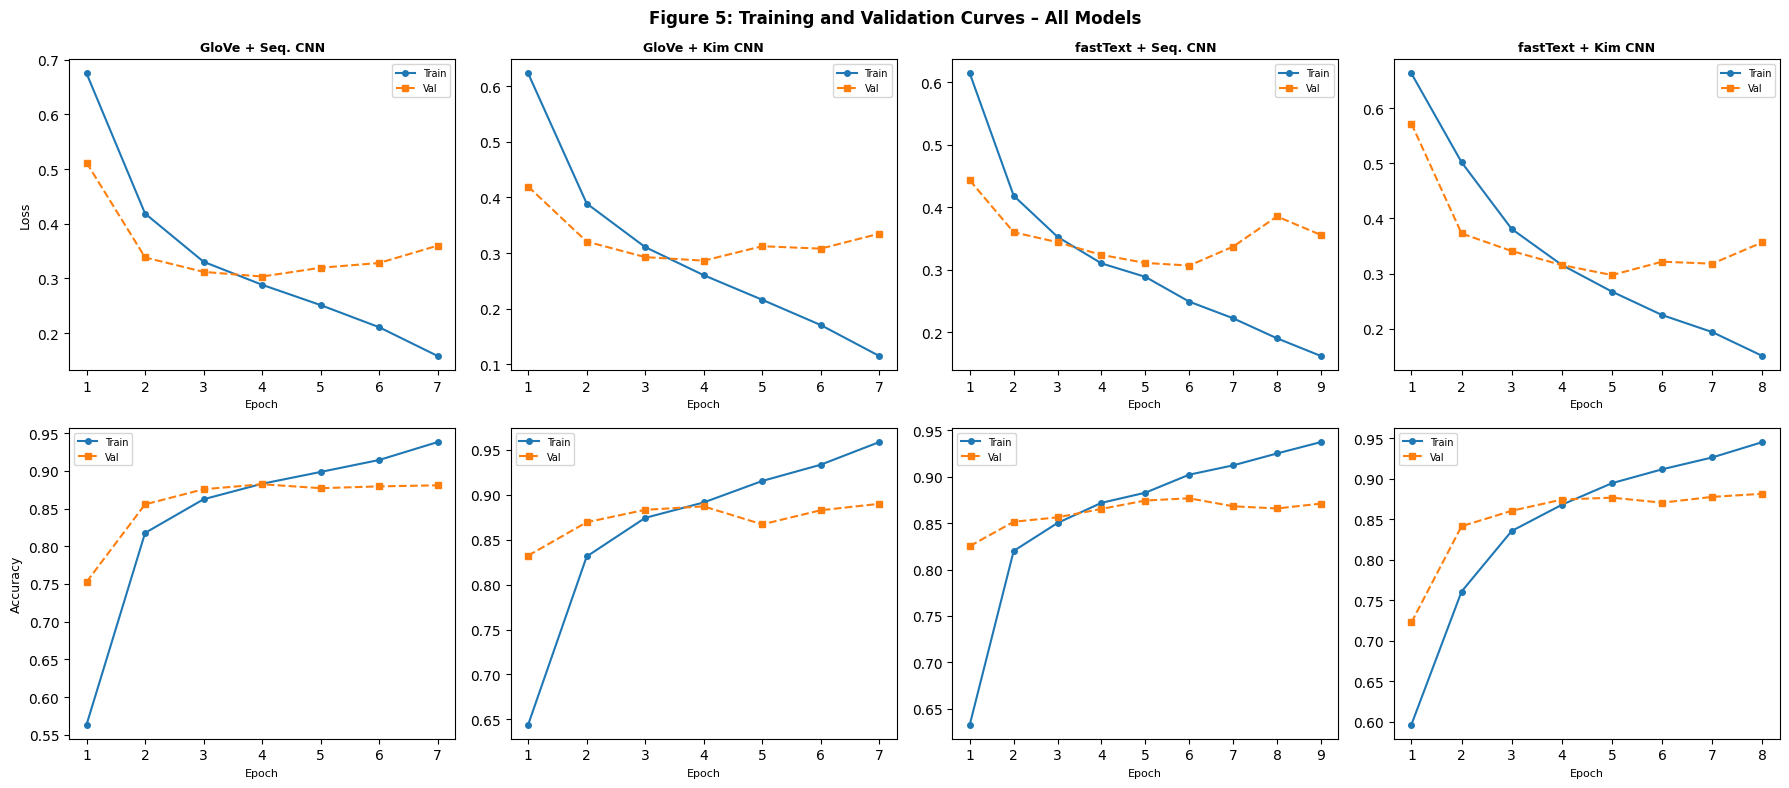

In [21]:
# Training and validation curves for all models
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
MODEL_LABELS = [
    'GloVe + Seq. CNN', 'GloVe + Kim CNN',
    'fastText + Seq. CNN', 'fastText + Kim CNN'
]
HIST_LIST    = [history1, history2, history3, history4]

for col, (hist, lbl) in enumerate(zip(HIST_LIST, MODEL_LABELS)):
    epochs = range(1, len(hist.history['loss']) + 1)
    # Row 0: loss
    axes[0, col].plot(epochs, hist.history['loss'],     'o-', ms=4, label='Train')
    axes[0, col].plot(epochs, hist.history['val_loss'], 's--', ms=4, label='Val')
    axes[0, col].set_title(lbl, fontsize=9, fontweight='bold')
    axes[0, col].set_xlabel('Epoch', fontsize=8)
    if col == 0:
        axes[0, col].set_ylabel('Loss', fontsize=9)
    axes[0, col].legend(fontsize=7)
    # Row 1: accuracy
    axes[1, col].plot(epochs, hist.history['accuracy'],     'o-', ms=4, label='Train')
    axes[1, col].plot(epochs, hist.history['val_accuracy'], 's--', ms=4, label='Val')
    axes[1, col].set_xlabel('Epoch', fontsize=8)
    if col == 0:
        axes[1, col].set_ylabel('Accuracy', fontsize=9)
    axes[1, col].legend(fontsize=7)

plt.suptitle('Figure 5: Training and Validation Curves – All Models',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_training_curves.pdf', format='pdf', bbox_inches='tight')
plt.show()




In [22]:
def evaluate_model(model, name: str):
    prob = model.predict(X_test, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)

    acc  = accuracy_score(y_test, pred)
    cm   = confusion_matrix(y_test, pred)
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)

    print(f"\n{'─'*58}")
    print(f"  {name}")
    print(f"{'─'*58}")
    print(f"  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  AUC-ROC  : {roc_auc:.4f}")
    print(f"\n  Confusion Matrix:\n{cm}")
    print(f"\n{classification_report(y_test, pred, target_names=['Negative','Positive'])}")

    return acc, roc_auc, fpr, tpr, cm, prob


In [23]:
from sklearn.metrics import (
    roc_curve, auc, accuracy_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
results = {}
for name, model in zip(MODEL_LABELS, [model1, model2, model3, model4]):
    acc, roc_auc, fpr, tpr, cm, prob = evaluate_model(model, name)
    results[name] = dict(acc=acc, auc=roc_auc, fpr=fpr, tpr=tpr, cm=cm, prob=prob)



──────────────────────────────────────────────────────────
  GloVe + Seq. CNN
──────────────────────────────────────────────────────────
  Accuracy : 0.8670  (86.70%)
  AUC-ROC  : 0.9449

  Confusion Matrix:
[[1884  214]
 [ 344 1755]]

              precision    recall  f1-score   support

    Negative       0.85      0.90      0.87      2098
    Positive       0.89      0.84      0.86      2099

    accuracy                           0.87      4197
   macro avg       0.87      0.87      0.87      4197
weighted avg       0.87      0.87      0.87      4197


──────────────────────────────────────────────────────────
  GloVe + Kim CNN
──────────────────────────────────────────────────────────
  Accuracy : 0.8802  (88.02%)
  AUC-ROC  : 0.9513

  Confusion Matrix:
[[1775  323]
 [ 180 1919]]

              precision    recall  f1-score   support

    Negative       0.91      0.85      0.88      2098
    Positive       0.86      0.91      0.88      2099

    accuracy                        

In [24]:
# Summary
summary_df = pd.DataFrame([
    {'Model': n,
     'Accuracy': f"{v['acc']:.4f}",
     'AUC-ROC' : f"{v['auc']:.4f}"}
    for n, v in results.items()
]).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

print("\nTable 1: Model Performance Summary (Test Set)")
print(summary_df.to_string(index=False))




Table 1: Model Performance Summary (Test Set)
              Model Accuracy AUC-ROC
    GloVe + Kim CNN   0.8802  0.9513
   GloVe + Seq. CNN   0.8670  0.9449
fastText + Seq. CNN   0.8661  0.9421
 fastText + Kim CNN   0.8706  0.9395


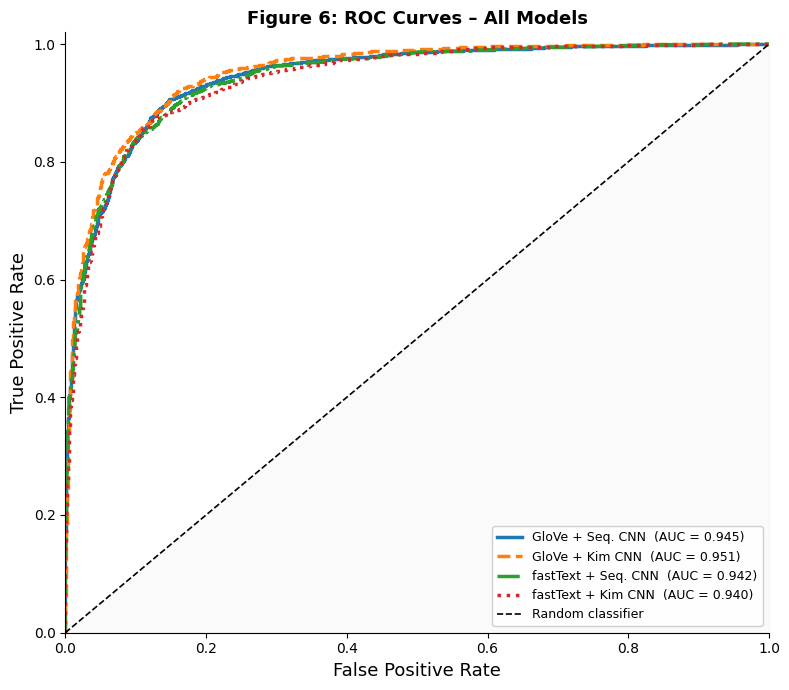

In [25]:
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
LS     = ['-', '--', '-.', ':']

fig, ax = plt.subplots(figsize=(8, 7))
for (name, res), col, ls in zip(results.items(), COLORS, LS):
    ax.plot(res['fpr'], res['tpr'], color=col, lw=2.5, linestyle=ls,
            label=f"{name}  (AUC = {res['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.04, color='grey')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('Figure 6: ROC Curves – All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.savefig('fig6_roc_curves.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


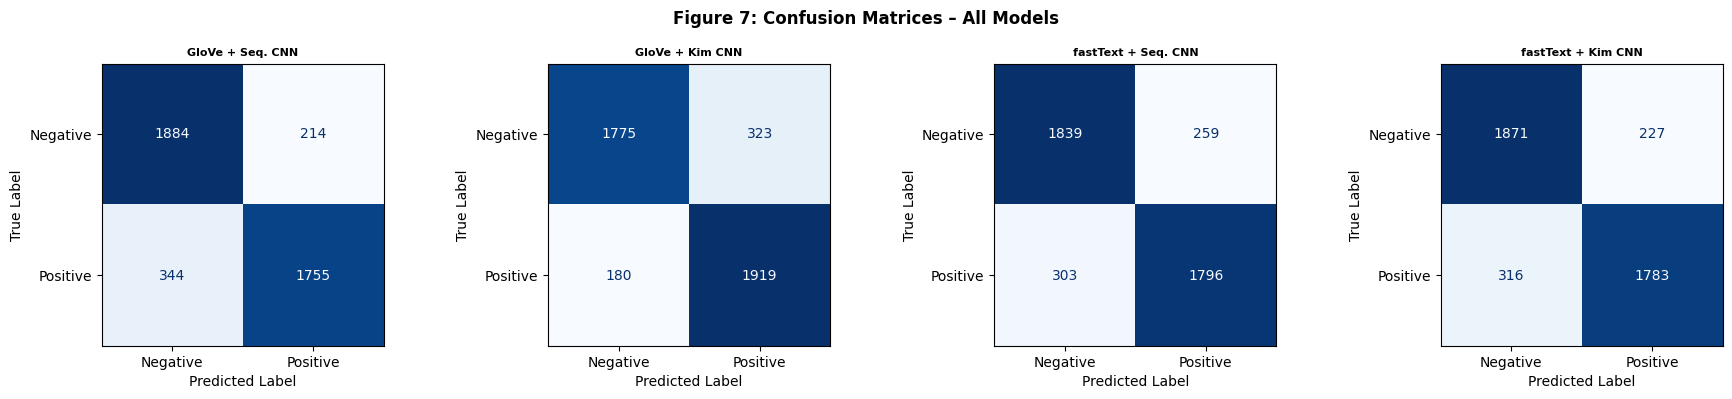

In [26]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, res) in zip(axes, results.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=res['cm'],
        display_labels=['Negative', 'Positive']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=8, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Figure 7: Confusion Matrices – All Models',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_confusion_matrices.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()




In [27]:
best_name  = max(results, key=lambda n: results[n]['auc'])
best_res   = results[best_name]
best_model = [model1, model2, model3, model4][MODEL_LABELS.index(best_name)]

print(f"\nBest model  : {best_name}")
print(f"Accuracy    : {best_res['acc']:.4f}")
print(f"AUC-ROC     : {best_res['auc']:.4f}")
best_model.summary()



Best model  : GloVe + Kim CNN
Accuracy    : 0.8802
AUC-ROC     : 0.9513


Model: "kim_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 400)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 400, 300)  │  6,000,300 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 400, 300)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2gram (Conv1D) │ (None, 399, 128)  │     76,928 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3gram (Conv1D) │ (None, 398, 128)  │    115,328 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4gram (Conv1D) │ (None, 397, 128)  │    153,728 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5gram (Conv1D) │ (None, 396, 128)  │    192,128 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmp_2gram           │ (None, 128)       │          0 │ conv_2gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmp_3gram           │ (None, 128)       │          0 │ conv_3gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmp_4gram           │ (None, 128)       │          0 │ conv_4gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmp_5gram           │ (None, 128)       │          0 │ conv_5gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 512)       │          0 │ gmp_2gram[0][0],  │
│ (Concatenate)       │                   │            │ gmp_3gram[0][0],  │
│                     │                   │            │ gmp_4gram[0][0],  │
│                     │                   │            │ gmp_5gram[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 256)       │    131,328 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 256)       │          0 │ dense1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense2 (Dense)      │ (None, 128)       │     32,896 │ dropout1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout2 (Dropout)  │ (None, 128)       │          0 │ dense2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ dropout2[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,107,697 (30.93 MB)

 Trainable params: 702,465 (2.68 MB)

 Non-trainable params: 6,000,300 (22.89 MB)

 Optimizer params: 1,404,932 (5.36 MB)

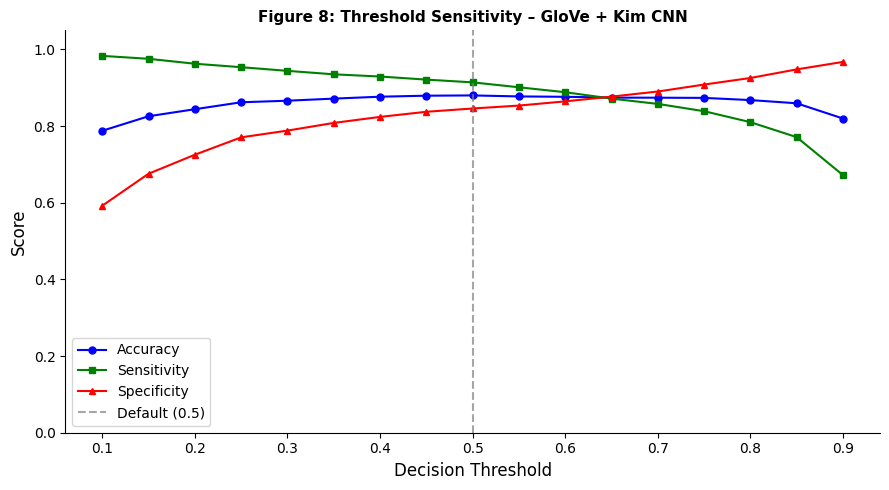

In [28]:
# Potential Decision-threshold sensitivity analysis for best model
thresholds = np.arange(0.10, 0.91, 0.05)
prob_arr   = best_res['prob']

rows = []
for t in thresholds:
    pred_t = (prob_arr >= t).astype(int)
    cm_t   = confusion_matrix(y_test, pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    rows.append({
        'Threshold'  : round(t, 2),
        'Accuracy'   : accuracy_score(y_test, pred_t),
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
    })
thresh_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresh_df['Threshold'], thresh_df['Accuracy'],    'b-o', ms=5, label='Accuracy')
ax.plot(thresh_df['Threshold'], thresh_df['Sensitivity'], 'g-s', ms=5, label='Sensitivity')
ax.plot(thresh_df['Threshold'], thresh_df['Specificity'], 'r-^', ms=5, label='Specificity')
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.7, label='Default (0.5)')
ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Figure 8: Threshold Sensitivity – {best_name}',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
sns.despine()
plt.tight_layout()
plt.savefig('fig8_threshold_sensitivity.pdf', format='pdf', bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
